In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from load_meop import MEOP
from region import Region
pfns = PlottingFns()

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import xesmf as xe
import matplotlib.patches as mpatches
import xeofs as xo
import cartopy


ARGO = '/nfs/b0133/eejco/data/ARGO/DataSelection_a0ad0869-68c3-4b7d-af4c-9c010ab6e378/'


# glaciers = {'mertz ':[144.25,-67.5],
#             'denman':[99.5, -66.75],
#             'conger':[103,-66],
#             'vanderford':[110, -66],
#             'totten':[116.33,-67],
glaciers = {'cook': [153,-69.5],
            'mertz': [144.25,-68.5]}

extent = [140,170,-74,-60]
extent_ea = [70,180,-74,-60]
extent_mi = [20,180,-74,-50]

In [4]:
#define helper functions
def get_trend(da: xr.DataArray,ns=True):
    ns_2_yr = lambda x: x * 1e9 * 60 * 60 * 24 * 365.25
    p = da.polyfit(dim='time',deg=1)
    m = p.polyfit_coefficients.sel(degree=1)
    m = m.assign_coords(longitude=da.longitude)
    return ns_2_yr(m) if ns else m

def crop_to_extent(ds, extent):
    return ds.where((ds.latitude >= extent[2]) & 
                    (ds.latitude <= extent[3]) &
                    (ds.longitude >= extent[0]) &
                    (ds.longitude <= extent[1]), drop=True)

def season_split(da):
    # divide by season
    months = da.time.dt.month
    seasons = dict()
    seasons['winter'] = da.where((months >=7) & (months <=9))
    seasons['spring'] = da.where((months >=10) & (months <=12))
    seasons['summer'] = da.where((months >=1) & (months <=3))
    seasons['autumn'] = da.where((months >=4) & (months <=6))
    return seasons

def seasonal_anomaly(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()

def plot_glaciers(ax):
    for label in glaciers:
        coords=glaciers[label]
        ax.text(coords[0],coords[1],label,transform=ccrs.PlateCarree(),size=8,c='w',ha='center',bbox=dict(boxstyle="square",facecolor='black',alpha=0.5))



In [5]:
sla0 = SLA(deg=0.25).da
sla1 = SLA(deg=1).da
dot = DOT().ds.dot

In [6]:
elevation = GEBCO(coarsen_factor=40).ds.elevation

In [7]:
an = lambda da: da.groupby('time.year').mean()
yr = lambda da: [pd.Timestamp(y.item(),1,1) for y in an(da).year]

In [8]:
dot_detrend =  utls.detrend_dim(dot,'time')
dot_anomaly = dot_detrend.groupby('time.month') - dot_detrend.groupby('time.month').mean()
sla_detrend =  utls.detrend_dim(sla0,'time')
sla_anomaly = sla_detrend.groupby('time.month') - sla_detrend.groupby('time.month').mean()
sla1_detrend =  utls.detrend_dim(sla1,'time')
sla1_anomaly = sla1_detrend.groupby('time.month') - sla1_detrend.groupby('time.month').mean()

/nfs/b0133/eejco/miniconda3/envs/sha-env/lib/python3.10/site-packages/xarray/core/nputils.py:248: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])


In [17]:
sla_mi = crop_to_extent(sla_anomaly,extent_mi).sel(time=slice(pd.Timestamp(2011,1,1),pd.Timestamp(2022,1,1)))
sla_mi_ = crop_to_extent(sla_detrend,extent_mi).sel(time=slice(pd.Timestamp(2011,1,1),pd.Timestamp(2022,1,1)))

sla_mi_full = crop_to_extent(sla_anomaly,extent_mi)
sla_do = crop_to_extent(sla1_anomaly,extent_mi).sel(time=slice(pd.Timestamp(2011,1,1),dot.time[-1]))
sla_ea = crop_to_extent(sla_anomaly,extent_ea)
sla_ex = crop_to_extent(sla_anomaly,extent)
dot_mi = crop_to_extent(dot_anomaly,extent_mi).sel(time=slice(pd.Timestamp(2011,1,1),pd.Timestamp(2022,1,1)))
dot_ea = crop_to_extent(dot_anomaly,extent_ea)
dot_ex = crop_to_extent(dot_anomaly,extent)
elev = crop_to_extent(elevation,extent_ea)

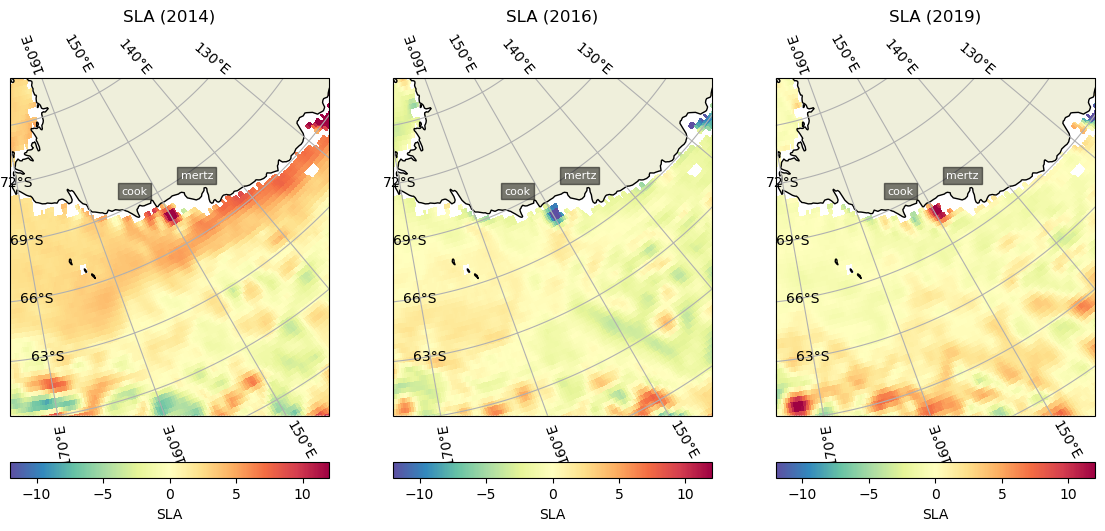

In [10]:
fig, ax = plt.subplots(1,3,figsize=(14,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax[0],an(sla_anomaly).sel(year=2014),cbar='SLA',vmax=12,title='SLA (2014)',extent=extent,cbar_orientation='horizontal',land_zorder=2)
pfns.sp(ax[1],an(sla_anomaly).sel(year=2016),cbar='SLA',vmax=12,title='SLA (2016)',extent=extent,cbar_orientation='horizontal',land_zorder=2)
pfns.sp(ax[2],an(sla_anomaly).sel(year=2019),cbar='SLA',vmax=12,title='SLA (2019)',extent=extent,cbar_orientation='horizontal',land_zorder=2)
plot_glaciers(ax[0])
plot_glaciers(ax[1])
plot_glaciers(ax[2])


In [24]:
modes = 3
model = xo.single.EOF(n_modes=modes)
model.fit(sla_mi_full.interpolate_na(dim='time'), dim="time")
#model.fit(sla_mi.interpolate_na(dim='time'), dim=('latitude','longitude'))


evr = model.explained_variance_ratio()

components = model.components() # eofs, [mode, lat, lon]

scores = model.scores() #pcas, [time, mode]

In [25]:
def plot_mode_ts(ax,mode):
    ax.plot(scores.time,scores.sel(mode=mode))

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.grid(True)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    
    ax.spines['bottom'].set_position('zero')

    ax.set_ylabel('Mode '+str(mode))
    ax.set_ylim([-420,420])

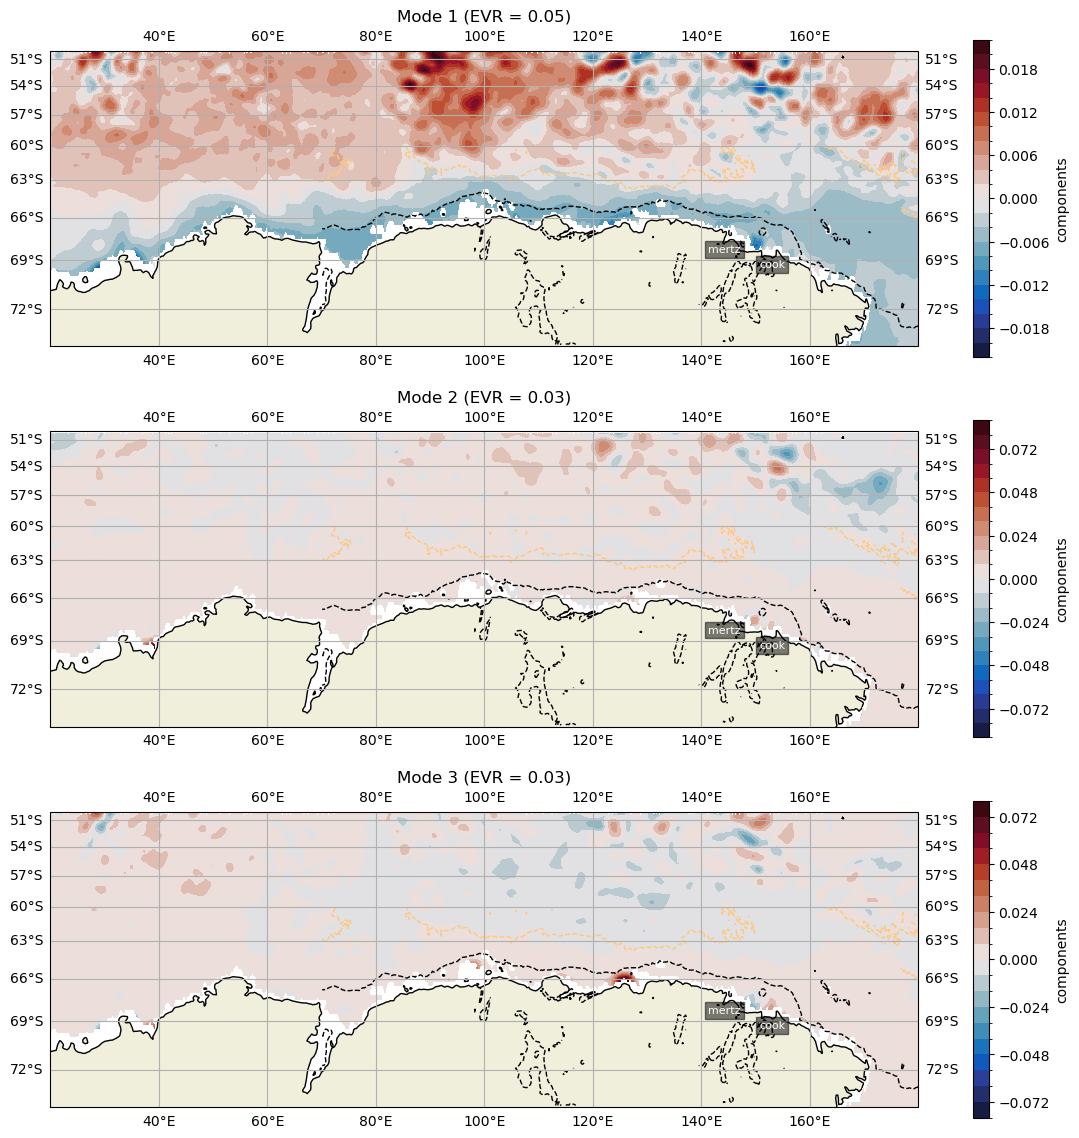

In [26]:
fig = plt.figure(figsize=(14,14))
axs=[]

gs = fig.add_gridspec(3,1)

axs.append(fig.add_subplot(gs[0, 0],projection=ccrs.Mercator()))
axs.append(fig.add_subplot(gs[1, 0],projection=ccrs.Mercator()))
axs.append(fig.add_subplot(gs[2, 0],projection=ccrs.Mercator()))


# plot maps
for n in list(range(modes)):
    m = n+1
    #pfns.sp(axs[n],components.sel(mode=m),title='Mode {} (EVR = {})'.format(m,round(evr[n].item(),2)),vmax=0.02,cmap='coolwarm', bathy=elevation, extent=extent_ea)
    components.sel(mode=m).plot.contourf(x='longitude',y='latitude',ax=axs[n],cmap=cmocean.cm.balance,transform=ccrs.PlateCarree(),levels=25)
    elev.plot.contour(x='longitude',y='latitude',ax=axs[n],levels=[-1000,-4000],transform=ccrs.PlateCarree(),cmap="copper_r",vmin=-10000,vmax=0,linewidths=1,linestyles='--')

    axs[n].set_title('Mode {} (EVR = {})'.format(m,round(evr[n].item(),2)))
    axs[n].set_extent(extent_mi,crs=ccrs.PlateCarree())
    axs[n].add_feature(cartopy.feature.LAND, edgecolor='k')
    plot_glaciers(axs[n])
    axs[n].gridlines(draw_labels=True)




In [14]:
sla_mi

<xarray.DataArray (time: 132, latitude: 97, longitude: 640)> Size: 66MB
array([[[            nan,             nan,             nan, ...,
          3.20867701e+00,  3.12010500e+00,  2.94076306e+00],
        [            nan,             nan,             nan, ...,
          3.27040377e+00,  3.32336846e+00,  3.21644103e+00],
        [            nan,             nan,             nan, ...,
          3.30301050e+00,  3.19372187e+00,  3.10339513e+00],
        ...,
        [-8.97669038e+00, -1.18333619e+01, -1.43463433e+01, ...,
          7.10298969e+00,  5.26215920e+00,  4.09164015e+00],
        [-1.16132567e+01, -1.34209627e+01, -1.54375269e+01, ...,
          7.67846460e+00,  6.74090854e+00,  5.76682186e+00],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]],

       [[            nan,             nan,             nan, ...,
          3.36802934e+00,  3.33149005e+00,  3.05599066e+00],
        [            nan,             nan,             nan, ...,
          3.14563964e+00,  3.00422010e+00,  2.72638894e+00],
        [            nan,             nan,             nan, ...,
          2.76970841e+00,  2.55790096e+00,  2.24122694e+00],
...
        [ 5.34673163e+00,  3.68175932e+00,  7.96971670e-01, ...,
         -5.33685490e+00, -4.05492148e+00, -2.49949912e+00],
        [ 4.11204145e+00,  1.64489281e+00, -1.60628889e+00, ...,
         -3.95531269e+00, -2.62178471e+00, -1.56070707e+00],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]],

       [[            nan,             nan,             nan, ...,
         -3.43043143e+00, -3.34127069e+00, -3.52426361e+00],
        [            nan,             nan,             nan, ...,
         -3.79005680e+00, -3.43041886e+00, -3.37425757e+00],
        [            nan,             nan,             nan, ...,
         -2.69211929e+00, -2.72394146e+00, -2.85088541e+00],
        ...,
        [ 9.17117487e+00,  8.48534103e+00,  7.29419126e+00, ...,
          4.62877609e+00,  3.68028824e+00,  5.26830786e+00],
        [ 8.60460912e+00,  8.43917914e+00,  7.39847903e+00, ...,
          3.55526133e+00,  3.54697683e+00,  5.63404316e+00],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]]])
Coordinates:
  * longitude  (longitude) float64 5kB 20.0 20.25 20.5 ... 179.2 179.5 179.8
  * latitude   (latitude) float64 776B -74.0 -73.75 -73.5 ... -50.5 -50.25 -50.0
  * time       (time) datetime64[ns] 1kB 2011-01-01 2011-02-01 ... 2021-12-01
    month      (time) int64 1kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Attributes:
    units:    cm

In [15]:
pnan_ = (np.isnan(sla_mi_full).sum('time')/len(sla_mi_full.time))*100
pnan=pnan_.where(pnan_<100,np.NaN)
allna = pnan_==100


In [16]:
np.isnan(sla_mi_full).sum()

<xarray.DataArray ()> Size: 8B
array(3894815)
Attributes:
    units:    cm

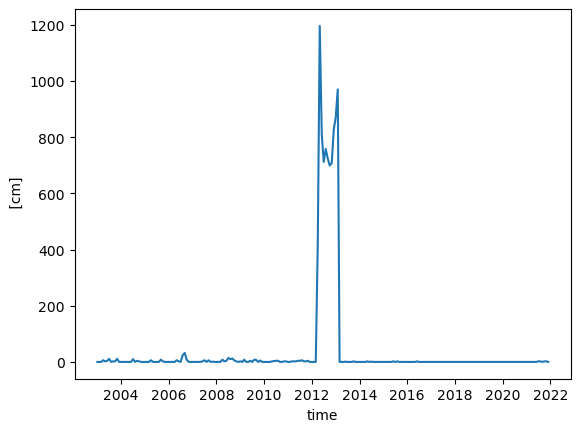

In [17]:
np.isnan(sla_mi_full).where(~allna).sum(['latitude','longitude']).plot()

In [18]:
allna = pnan_==100
np.isnan(sla_mi_full)#.where(allna,False)

<xarray.DataArray (time: 228, latitude: 97, longitude: 640)> Size: 14MB
array([[[ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [ True,  True,  True, ...,  True,  True,  True]],

       [[ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [ True,  True,  True, ...,  True,  True,  True]],

       [[ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        ...,
...
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [ True,  True,  True, ...,  True,  True,  True]],

       [[ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [ True,  True,  True, ...,  True,  True,  True]],

       [[ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [ True,  True,  True, ...,  True,  True,  True]]])
Coordinates:
  * longitude  (longitude) float64 5kB 20.0 20.25 20.5 ... 179.2 179.5 179.8
  * latitude   (latitude) float64 776B -74.0 -73.75 -73.5 ... -50.5 -50.25 -50.0
  * time       (time) datetime64[ns] 2kB 2003-01-01 2003-02-01 ... 2021-12-01
    month      (time) int64 2kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Attributes:
    units:    cm

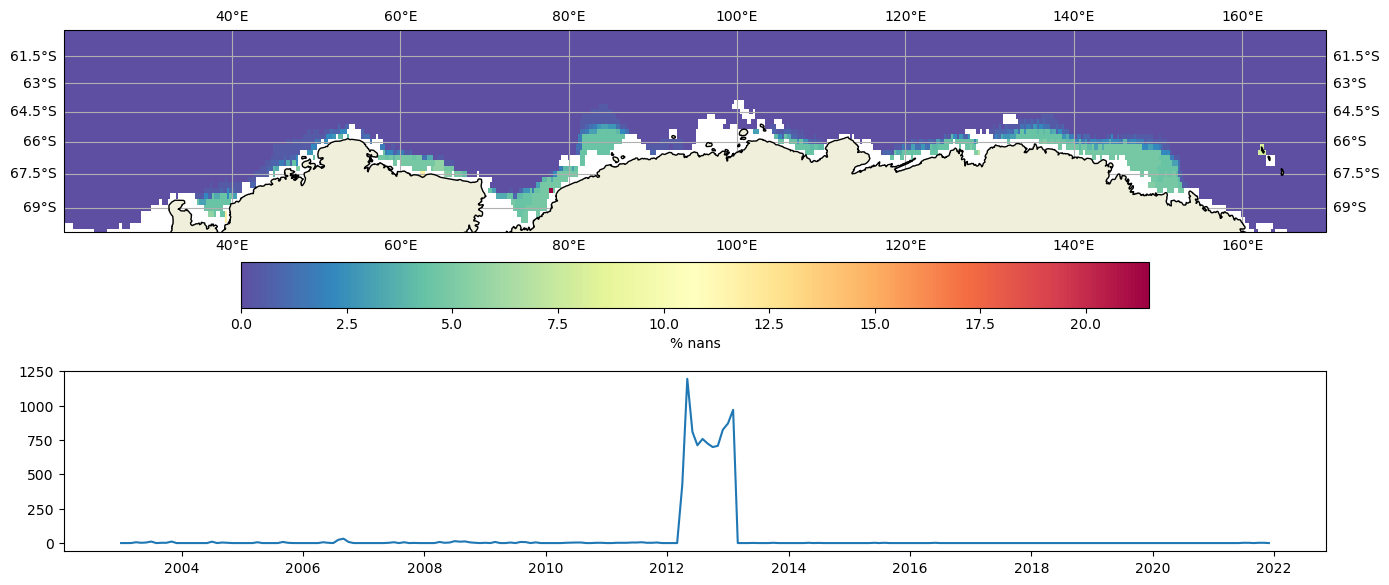

In [19]:
fig = plt.figure(figsize=(14,6))
axs=[]

gs = fig.add_gridspec(5,1)

axs.append(fig.add_subplot(gs[0:3, 0],projection=ccrs.Mercator()))
axs.append(fig.add_subplot(gs[3:5, 0]))

pfns.sp(axs[0],pnan,cbar='% nans',cbar_orientation='horizontal',extent=[20,170,-70,-60])
axs[1].plot(sla_mi_full.time,np.isnan(sla_mi_full).where(~allna).sum(['latitude','longitude']))

plt.tight_layout()

In [20]:
sla_mask=np.isnan(sla_mi).where(pnan==np.NaN,10000)

In [21]:
sla_mask

<xarray.DataArray (time: 132, latitude: 97, longitude: 640)> Size: 66MB
array([[[10000, 10000, 10000, ..., 10000, 10000, 10000],
        [10000, 10000, 10000, ..., 10000, 10000, 10000],
        [10000, 10000, 10000, ..., 10000, 10000, 10000],
        ...,
        [10000, 10000, 10000, ..., 10000, 10000, 10000],
        [10000, 10000, 10000, ..., 10000, 10000, 10000],
        [10000, 10000, 10000, ..., 10000, 10000, 10000]],

       [[10000, 10000, 10000, ..., 10000, 10000, 10000],
        [10000, 10000, 10000, ..., 10000, 10000, 10000],
        [10000, 10000, 10000, ..., 10000, 10000, 10000],
        ...,
        [10000, 10000, 10000, ..., 10000, 10000, 10000],
        [10000, 10000, 10000, ..., 10000, 10000, 10000],
        [10000, 10000, 10000, ..., 10000, 10000, 10000]],

       [[10000, 10000, 10000, ..., 10000, 10000, 10000],
        [10000, 10000, 10000, ..., 10000, 10000, 10000],
        [10000, 10000, 10000, ..., 10000, 10000, 10000],
        ...,
...
        ...,
        [10000, 10000, 10000, ..., 10000, 10000, 10000],
        [10000, 10000, 10000, ..., 10000, 10000, 10000],
        [10000, 10000, 10000, ..., 10000, 10000, 10000]],

       [[10000, 10000, 10000, ..., 10000, 10000, 10000],
        [10000, 10000, 10000, ..., 10000, 10000, 10000],
        [10000, 10000, 10000, ..., 10000, 10000, 10000],
        ...,
        [10000, 10000, 10000, ..., 10000, 10000, 10000],
        [10000, 10000, 10000, ..., 10000, 10000, 10000],
        [10000, 10000, 10000, ..., 10000, 10000, 10000]],

       [[10000, 10000, 10000, ..., 10000, 10000, 10000],
        [10000, 10000, 10000, ..., 10000, 10000, 10000],
        [10000, 10000, 10000, ..., 10000, 10000, 10000],
        ...,
        [10000, 10000, 10000, ..., 10000, 10000, 10000],
        [10000, 10000, 10000, ..., 10000, 10000, 10000],
        [10000, 10000, 10000, ..., 10000, 10000, 10000]]])
Coordinates:
  * longitude  (longitude) float64 5kB 20.0 20.25 20.5 ... 179.2 179.5 179.8
  * latitude   (latitude) float64 776B -74.0 -73.75 -73.5 ... -50.5 -50.25 -50.0
  * time       (time) datetime64[ns] 1kB 2011-01-01 2011-02-01 ... 2021-12-01
    month      (time) int64 1kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Attributes:
    units:    cm

In [22]:
dot_mi

<xarray.DataArray (time: 94, latitude: 48, longitude: 160)> Size: 6MB
array([[[        nan,         nan,         nan, ...,  0.88007767,
          0.91592755,  0.8894272 ],
        [        nan,         nan,         nan, ...,  0.80880468,
          0.85403209,  0.84529694],
        [        nan,         nan,         nan, ...,  0.72628687,
          0.7744959 ,  0.77943634],
        ...,
        [-3.64465089, -3.74804246, -3.97855892, ...,  4.96097756,
          4.49054607,  3.82465197],
        [-3.89702282, -4.00233722, -4.23650461, ...,  5.06446066,
          4.55139003,  3.89109803],
        [-4.02831832, -4.13637705, -4.37254459, ...,  5.09817365,
          4.5673809 ,  3.91786363]],

       [[        nan,         nan,         nan, ...,  1.70770538,
          1.90397911,  2.05268103],
        [        nan,         nan,         nan, ...,  1.57807038,
          1.79293482,  1.98240041],
        [        nan,         nan,         nan, ...,  1.39967979,
          1.61076148,  1.81769549],
...
        [ 2.34961864,  2.55986139,  2.79260301, ...,  6.12028021,
          6.20157137,  5.98036842],
        [ 2.65833645,  2.87655084,  3.10249654, ...,  5.35190304,
          5.51355458,  5.40893022],
        [ 2.83034546,  3.05050086,  3.27042843, ...,  4.95767997,
          5.15717353,  5.10820123]],

       [[        nan,         nan,         nan, ..., -3.12735857,
         -3.17238639, -3.11921722],
        [        nan,         nan,         nan, ..., -3.14127105,
         -3.19122239, -3.12721207],
        [        nan,         nan,         nan, ..., -3.07858917,
         -3.13405155, -3.0636587 ],
        ...,
        [ 1.42965996,  1.83304736,  2.16220809, ...,  4.39959955,
          4.02832615,  3.72886184],
        [ 1.86652332,  2.29450422,  2.62255745, ...,  3.88848522,
          3.62466726,  3.45173354],
        [ 2.11293053,  2.55401733,  2.88080021, ...,  3.62690177,
          3.41929951,  3.31155397]]])
Coordinates:
  * longitude  (longitude) float64 1kB 20.5 21.5 22.5 23.5 ... 177.5 178.5 179.5
  * latitude   (latitude) float64 384B -73.75 -73.25 -72.75 ... -50.75 -50.25
  * time       (time) datetime64[ns] 752B 2011-01-01 2011-02-01 ... 2018-10-01
    month      (time) int64 752B 1 2 3 4 5 6 7 8 9 10 ... 1 2 3 4 5 6 7 8 9 10
Attributes:
    units:        cm
    long_name:    dynamic_ocean_topography
    description:  dynamic ocean topography (original)

In [23]:
model_sla = xo.single.EOF(n_modes=1)
model_dot = xo.single.EOF(n_modes=1)
model_sla.fit(sla_do.interpolate_na(dim='time'), dim="time")
model_dot.fit(dot_mi,dim='time')
evr_sla = model_sla.explained_variance_ratio()
evr_dot = model_dot.explained_variance_ratio()
components_sla = model_sla.components()
components_dot = model_dot.components()


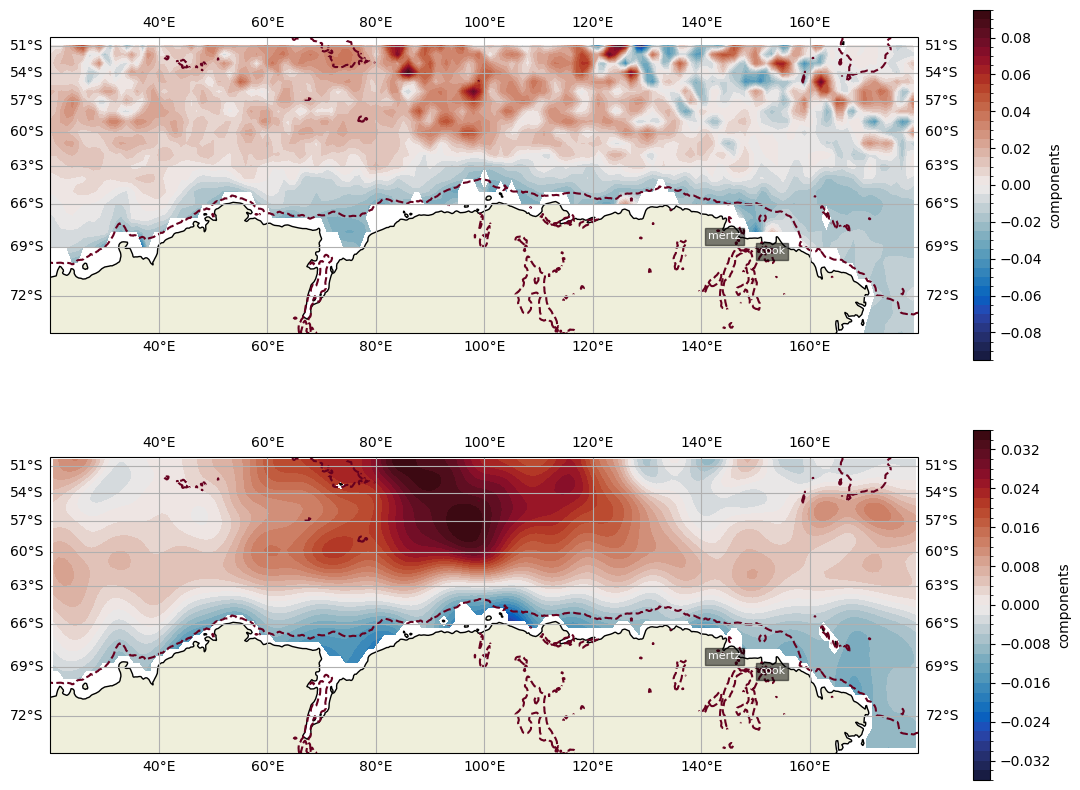

In [24]:
fig = plt.figure(figsize=(14,10))
axs=[]

gs = fig.add_gridspec(2,1)

axs.append(fig.add_subplot(gs[0, 0],projection=ccrs.Mercator()))
axs.append(fig.add_subplot(gs[1, 0],projection=ccrs.Mercator()))

# plot maps
def plot_component(n,comp,evr,title):
    comp.plot.contourf(x='longitude',y='latitude',ax=axs[n],cmap=cmocean.cm.balance,transform=ccrs.PlateCarree(),levels=40)
    axs[n].set_title(title + '(Mode 1, EVR = {})'.format(round(evr[0].item(),2)))
    axs[n].set_extent(extent_mi,crs=ccrs.PlateCarree())
    axs[n].add_feature(cartopy.feature.LAND, edgecolor='k')
    plot_glaciers(axs[n])
    axs[n].gridlines(draw_labels=True)
    elevation.plot.contour(x='longitude',y='latitude',ax=axs[n],transform=ccrs.PlateCarree(),levels=[-1000],linestyle='--',c='k')

plot_component(0,components_sla.sel(mode=1),evr_sla,'SLA1')
plot_component(1,components_dot.sel(mode=1),evr_dot,'DOT')


In [ ]:
modes = 3
model = xo.single.EOF(n_modes=modes)
#model.fit(sla_ex.interpolate_na(dim='time'), dim="time")
model.fit(dot_mi,dim='time')
evr = model.explained_variance_ratio()
components = model.components() # eofs, [mode, lat, lon]
scores = model.scores() #pcas, [time, mode]

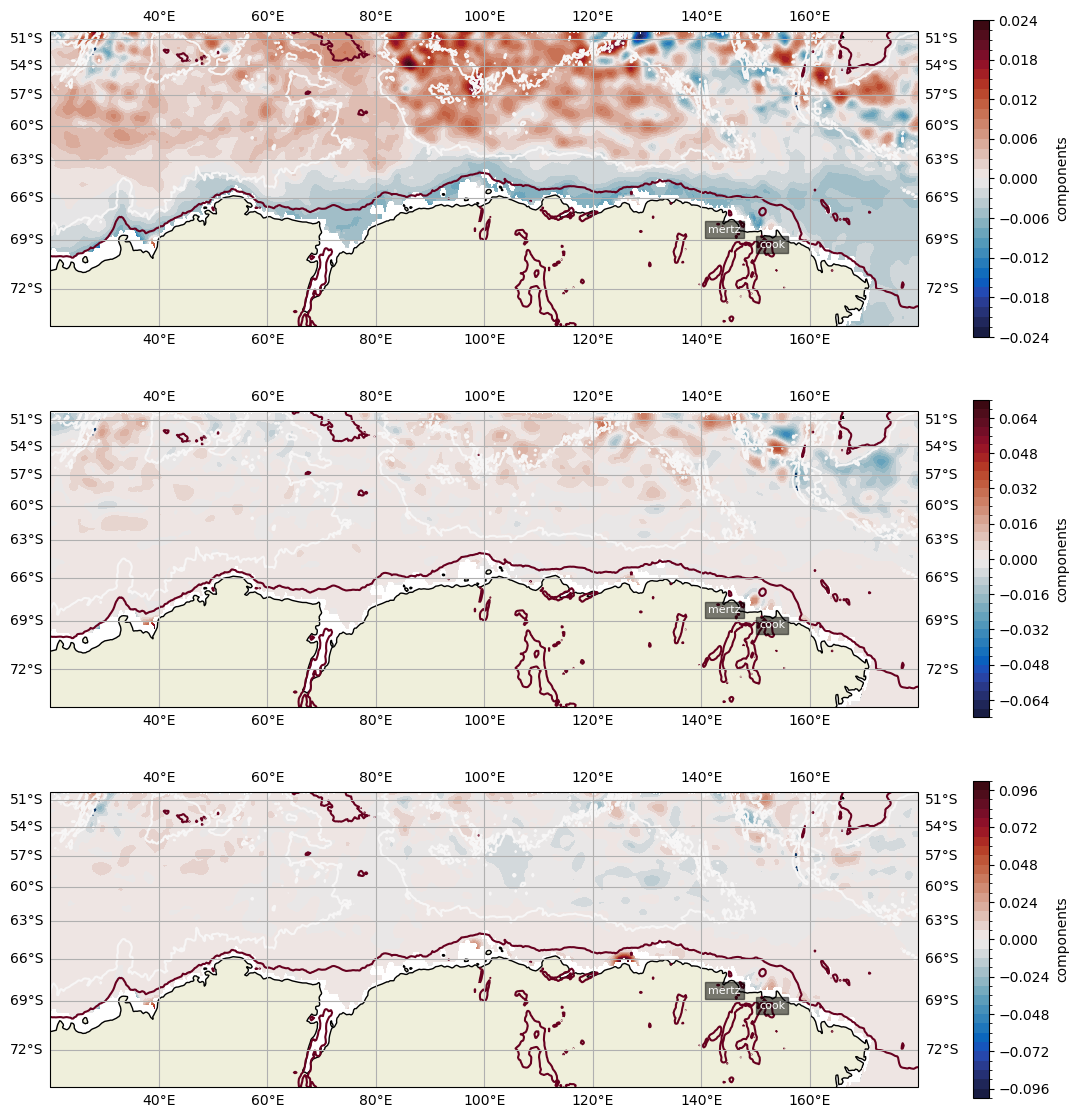

In [26]:
fig = plt.figure(figsize=(14,14))
axs=[]

gs = fig.add_gridspec(3,1)

axs.append(fig.add_subplot(gs[0, 0],projection=ccrs.Mercator()))
axs.append(fig.add_subplot(gs[1, 0],projection=ccrs.Mercator()))
axs.append(fig.add_subplot(gs[2, 0],projection=ccrs.Mercator()))


# plot maps
for n in list(range(modes)):
    m = n+1
    #pfns.sp(axs[n],components.sel(mode=m),title='Mode {} (EVR = {})'.format(m,round(evr[n].item(),2)),vmax=0.02,cmap='coolwarm', bathy=elevation, extent=extent_ea)
    components.sel(mode=m).plot.contourf(x='longitude',y='latitude',ax=axs[n],cmap=cmocean.cm.balance,transform=ccrs.PlateCarree(),levels=40)
    axs[n].set_title('Mode {} (EVR = {})'.format(m,round(evr[n].item(),2)))
    axs[n].set_extent(extent_mi,crs=ccrs.PlateCarree())
    axs[n].add_feature(cartopy.feature.LAND, edgecolor='k')
    plot_glaciers(axs[n])
    axs[n].gridlines(draw_labels=True)
    elevation.plot.contour(x='longitude',y='latitude',ax=axs[n],transform=ccrs.PlateCarree(),levels=[-1000,-4000,-6000],linestyle='--',c='k')


In [48]:
modes = 3
model = xo.single.EOF(n_modes=modes)
model.fit(sla_ex.interpolate_na(dim='time'), dim="time")

evr = model.explained_variance_ratio()

components = model.components() # eofs, [mode, lat, lon]

scores = model.scores() #pcas, [time, mode]

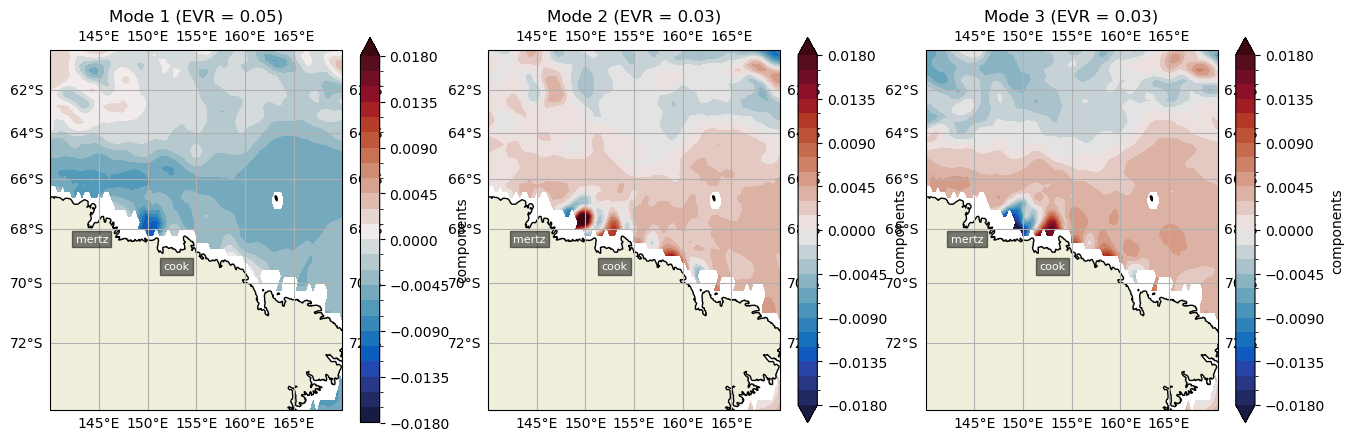

In [76]:
fig = plt.figure(figsize=(16,5))
axs=[]

gs = fig.add_gridspec(1,3)

axs.append(fig.add_subplot(gs[0, 0],projection=ccrs.Mercator()))
axs.append(fig.add_subplot(gs[0, 1],projection=ccrs.Mercator()))
axs.append(fig.add_subplot(gs[0, 2],projection=ccrs.Mercator()))

# plot maps
for n in list(range(modes)):
    m = n+1
    #pfns.sp(axs[n],components.sel(mode=m),title='Mode {} (EVR = {})'.format(m,round(evr[n].item(),2)),vmax=0.02,cmap='coolwarm', bathy=elevation, extent=extent_ea)
    components.sel(mode=m).plot.contourf(x='longitude',y='latitude',ax=axs[n],cmap=cmocean.cm.balance,vmax=0.018,vmin=-0.018,transform=ccrs.PlateCarree(),levels=25)
    axs[n].set_title('Mode {} (EVR = {})'.format(m,round(evr[n].item(),2)))
    axs[n].set_extent(extent,crs=ccrs.PlateCarree())
    axs[n].add_feature(cartopy.feature.LAND, edgecolor='k')
    plot_glaciers(axs[n])
    axs[n].gridlines(draw_labels=True)






In [77]:
sla_detrend =  utls.detrend_dim(sla0.sel(time=slice(pd.Timestamp(2011,1,1),pd.Timestamp(2021,12,30))),'time')
sla_anomaly = sla_detrend.groupby('time.month') - sla_detrend.groupby('time.month').mean()
sla_mi = crop_to_extent(sla_anomaly,extent_mi)
sla_ea = crop_to_extent(sla_anomaly,extent_ea)
sla_ex = crop_to_extent(sla_anomaly,extent)

/nfs/b0133/eejco/miniconda3/envs/sha-env/lib/python3.10/site-packages/xarray/core/nputils.py:248: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])


In [78]:
modes = 3
model = xo.single.EOF(n_modes=modes)
model.fit(sla_mi.interpolate_na(dim='time'), dim="time")

evr = model.explained_variance_ratio()

components = model.components() # eofs, [mode, lat, lon]

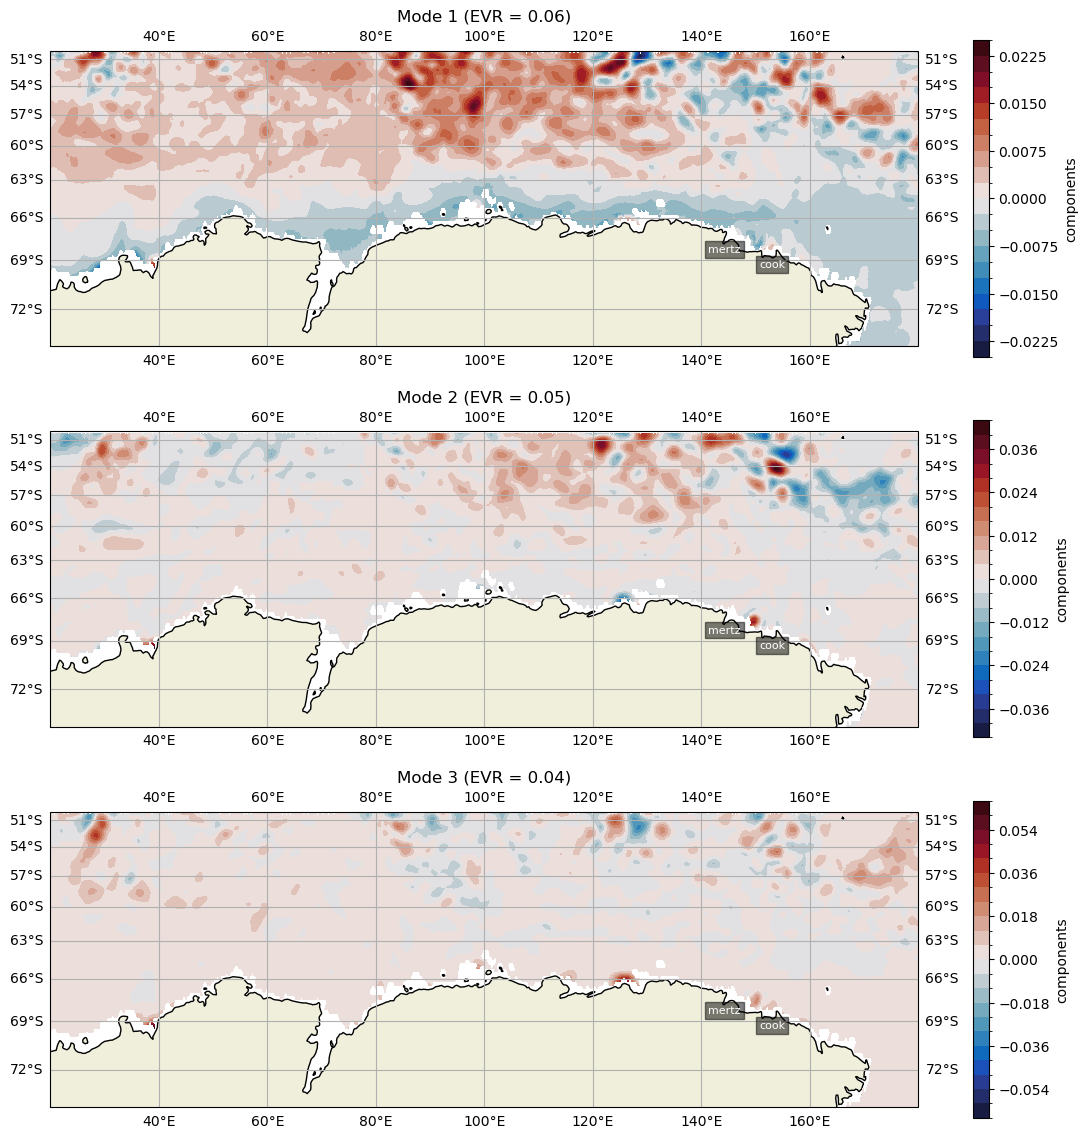

In [79]:
fig = plt.figure(figsize=(14,14))
axs=[]

gs = fig.add_gridspec(3,1)

axs.append(fig.add_subplot(gs[0, 0],projection=ccrs.Mercator()))
axs.append(fig.add_subplot(gs[1, 0],projection=ccrs.Mercator()))
axs.append(fig.add_subplot(gs[2, 0],projection=ccrs.Mercator()))


# plot maps
for n in list(range(modes)):
    m = n+1
    #pfns.sp(axs[n],components.sel(mode=m),title='Mode {} (EVR = {})'.format(m,round(evr[n].item(),2)),vmax=0.02,cmap='coolwarm', bathy=elevation, extent=extent_ea)
    components.sel(mode=m).plot.contourf(x='longitude',y='latitude',ax=axs[n],cmap=cmocean.cm.balance,transform=ccrs.PlateCarree(),levels=25)
    axs[n].set_title('Mode {} (EVR = {})'.format(m,round(evr[n].item(),2)))
    axs[n].set_extent(extent_mi,crs=ccrs.PlateCarree())
    axs[n].add_feature(cartopy.feature.LAND, edgecolor='k')
    plot_glaciers(axs[n])
    axs[n].gridlines(draw_labels=True)

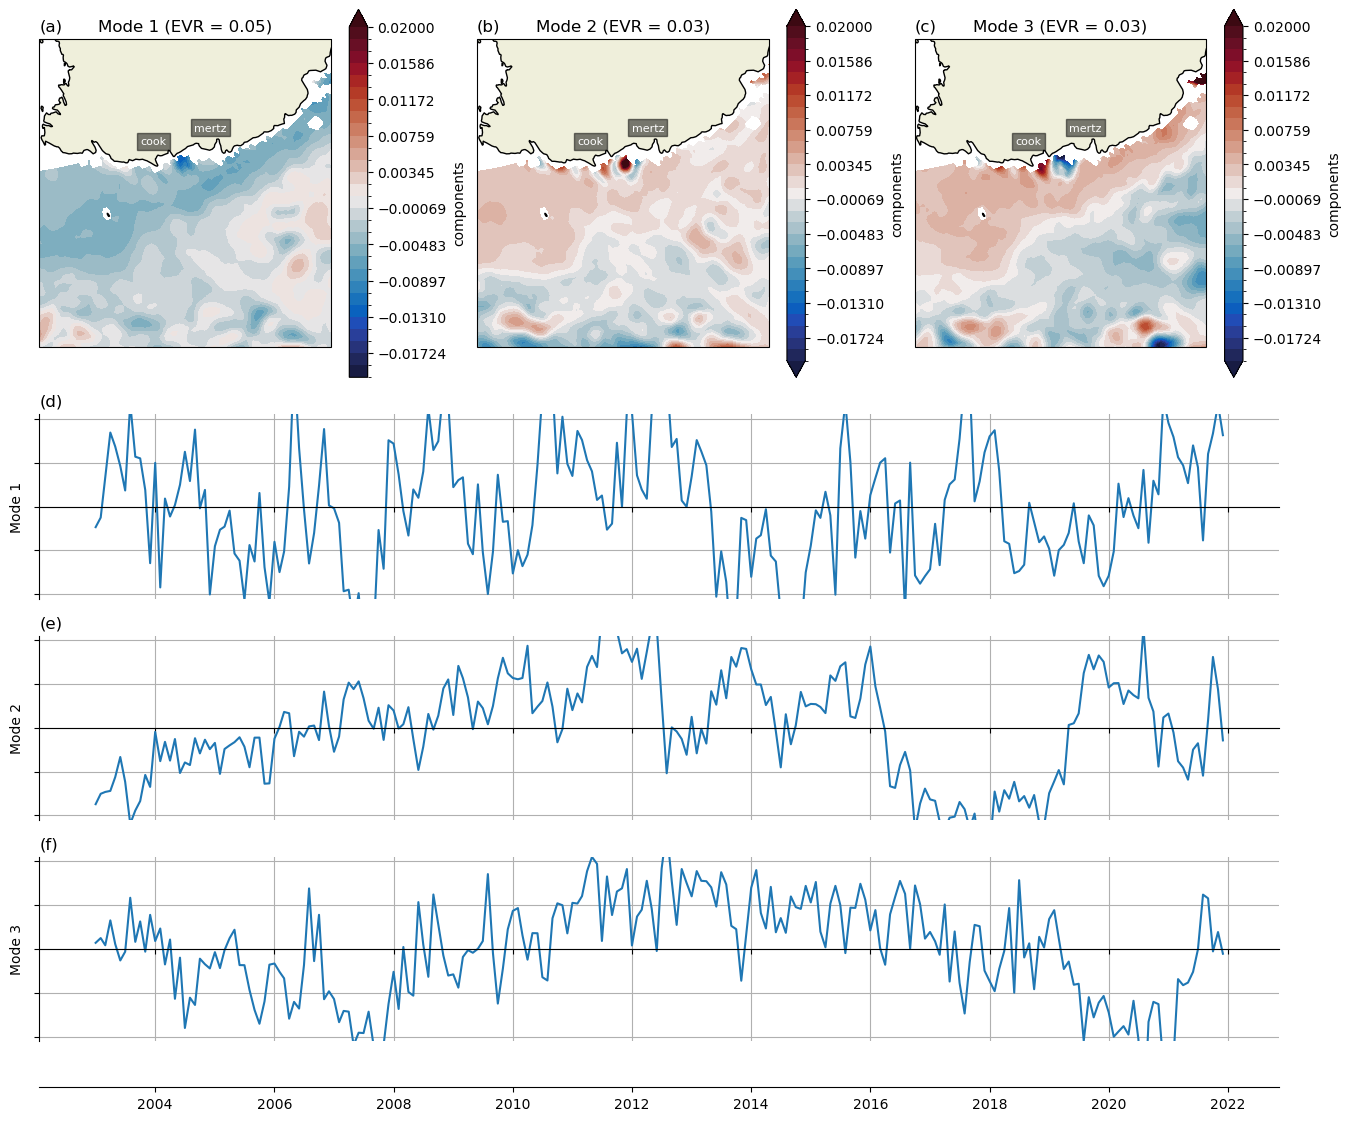

In [47]:
fig = plt.figure(figsize=(16,14))
axs=[]

gs = fig.add_gridspec(5,3,height_ratios=[40,20,20,20,1])

axs.append(fig.add_subplot(gs[0, 0],projection=ccrs.SouthPolarStereo()))
axs.append(fig.add_subplot(gs[0, 1],projection=ccrs.SouthPolarStereo()))
axs.append(fig.add_subplot(gs[0, 2],projection=ccrs.SouthPolarStereo()))

axs.append(fig.add_subplot(gs[1, 0:3]))
axs.append(fig.add_subplot(gs[2, 0:3]))
axs.append(fig.add_subplot(gs[3, 0:3]))
axs.append(fig.add_subplot(gs[4, 0:3]))

# plot maps
for n in list(range(modes)):
    m = n+1
    #pfns.sp(axs[n],components.sel(mode=m),title='Mode {} (EVR = {})'.format(m,round(evr[n].item(),2)),vmax=0.02,cmap='coolwarm', bathy=elevation, extent=extent_ea)
    components.sel(mode=m).plot.contourf(x='longitude',y='latitude',ax=axs[n],cmap=cmocean.cm.balance,vmax=0.02,transform=ccrs.PlateCarree(),levels=30)
    axs[n].set_title('Mode {} (EVR = {})'.format(m,round(evr[n].item(),2)))
    axs[n].set_extent(extent)
    axs[n].add_feature(cartopy.feature.LAND, edgecolor='k')
    plot_glaciers(axs[n])


#plot timeseries
for n in list(range(modes)):
    plot_mode_ts(axs[n+3],n+1)


#plot time
axs[6].plot(scores.time,scores.sel(mode=2),alpha=0)
axs[6].spines['left'].set_visible(False)
axs[6].yaxis.set_visible(False)
axs[6].spines['top'].set_visible(False)
axs[6].spines['right'].set_visible(False)




In [ ]:
fig, ax = plt.subplots(1,2,figsize=(12,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax[0],sla_anomaly.sel(time=pd.Timestamp(2017,12,1),method='nearest'),cbar='SLA',vmax=12,title='SLA (December 2017)',extent=extent,cbar_orientation='vertical',land_zorder=2)
pfns.sp(ax[1],sla_anomaly.sel(time=pd.Timestamp(2019,7,1),method='nearest'),cbar='SLA',vmax=12,title='SLA (July 2019)',extent=extent,cbar_orientation='vertical',land_zorder=2)
plot_glaciers(ax[0])
plot_glaciers(ax[1])

In [11]:
sice = xr.open_dataset('../data/NSIDC/sice_processed.nc')
sice = sice.__xarray_dataarray_variable__
sice = sice.sel(time=slice(sla.time[0],sla.time[-1]))


array([0, 1, 2, 3, 4, 5, 6, 7, 8])

Adding row: Cook
Adding row: Cook
Adding row: Cook Local
Adding row: Hotspot
Rendering..


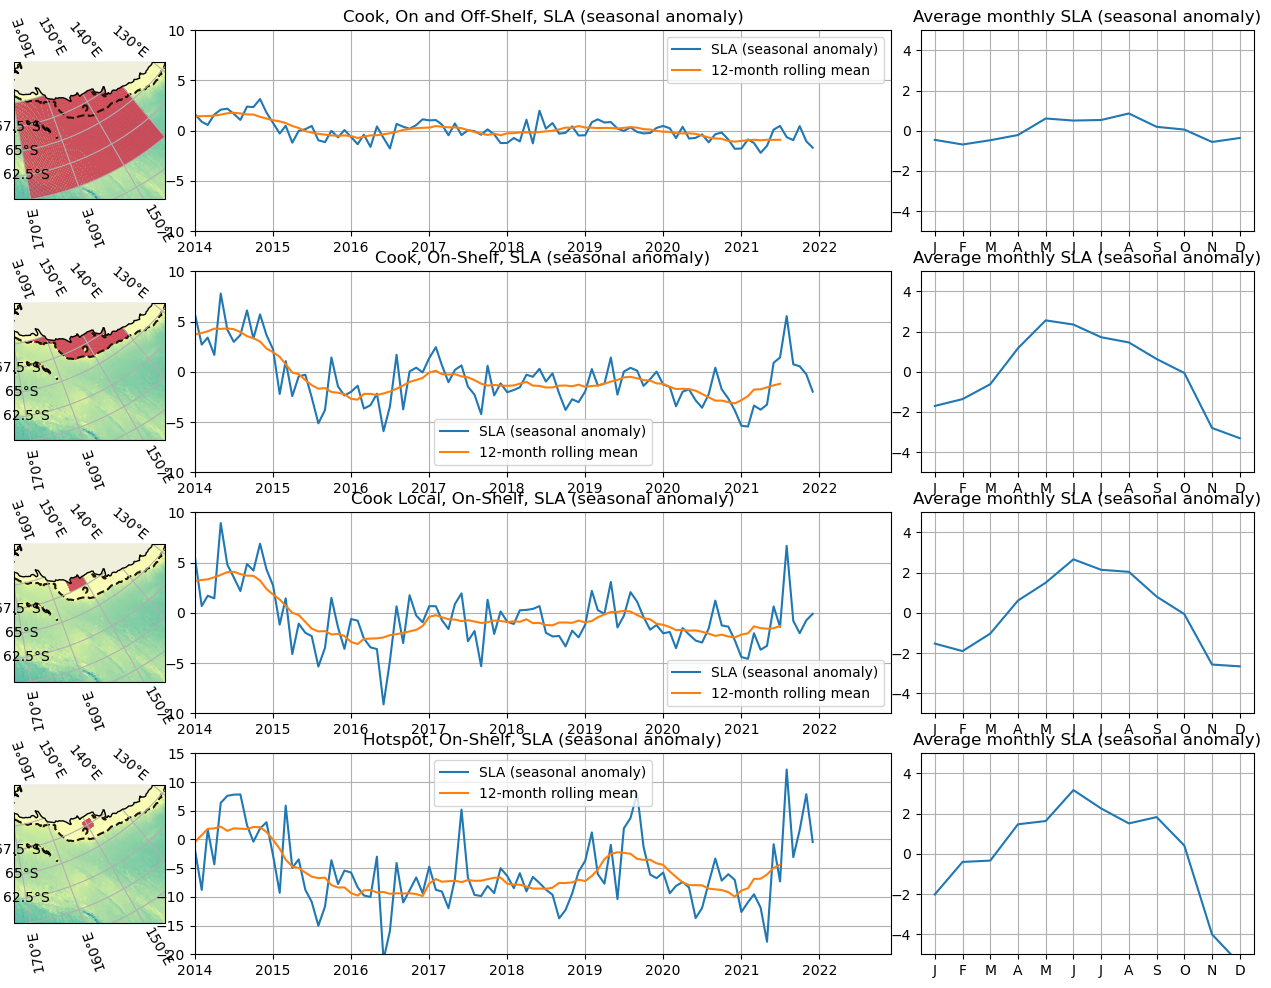

In [28]:
# compare small mertz area to:
# - extended shelf region (135-145)
# - EA south of Amery
# - whole SO (shelf)
fig = plt.figure(figsize=(16,12))
axs=[]

gs = fig.add_gridspec(4,7)

def add_row_anom(n,var,varname,title,extent,map_extent,shelf=False,ylim=[-10,10],ylim_cmt=[-5,5]):

    print('Adding row: ' + title)

    axs.append(fig.add_subplot(gs[n, 0],projection=ccrs.SouthPolarStereo()))
    axs.append(fig.add_subplot(gs[n,1:5]))
    axs.append(fig.add_subplot(gs[n,5:7]))

    if shelf == True:
        region = Region(title, extent, elevation, min_elevation = -1000)
    else:
        region = Region(title, extent, elevation)
    region.plot_region(ax=axs[n*3],da=elevation,extent=map_extent)

    da = region.crop_da(var)

    ax = axs[(n*3)+1]

    cmt = da.groupby('time.month').mean()
    anm = da.groupby('time.month') - cmt
    varname = varname + ' (seasonal anomaly)'

    ax.plot(anm.time,anm.mean(['latitude','longitude']),label=varname)
    #ax.plot(yr(da),an(da).mean(['latitude','longitude']),label=varname + ' ANNUAL')
    ax.plot(anm.time,anm.mean(['latitude','longitude']).rolling(time=12,center=True).mean(),label='12-month rolling mean')

    shelf_str = 'On' if shelf else 'On and Off'
    ax.set_title(title +', '+shelf_str+'-Shelf, ' + varname)
    ax.legend(loc='best')
    ax.set_ylim(ylim)
    ax.set_xlim([pd.Timestamp(2014,1,1),pd.Timestamp(2022,12,1)])
    ax.grid()

    ax = axs[(n*3)+2]

    ax.plot(cmt.month,cmt.mean(['latitude','longitude']))
    ax.set_ylim(ylim_cmt)
    ax.grid()
    ax.set_xticks(np.arange(12)+1)
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.set_xlim([0.5,12.5])
    ax.set_title('Average monthly '+varname)

add_row_anom(0,sha_ds_sla.ssha,'SLA','Cook',extent,extent,shelf=False)
add_row_anom(1,sha_ds_sla.ssha,'SLA','Cook',extent,extent,shelf=True)
add_row_anom(2,sha_ds_sla.ssha,'SLA','Cook Local',[150,155,-70,-67.5],extent,shelf=True)
add_row_anom(3,sha_ds_sla.ssha,'SLA','Hotspot',[148.5,151,-68,-67],extent,shelf=True,ylim=[-20,15])


print('Rendering..')
